In [1]:
!pip install ibapi
!pip install lightgbm

In [2]:
forecasting_horizon = 10
input_chunk_length = 180
ticker = 'AAPL'
interval = "minute"
interval_range = 5
days = 100

<h1>Imports</h1>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import os
import re
import joblib


import time
import requests
from datetime import datetime, timedelta
from bs4 import BeautifulSoup

from sklearn.preprocessing import LabelEncoder

from darts.models.forecasting.tft_model import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.timeseries import TimeSeries

In [4]:
from news import scrape_insider_data, scrape_congress_trading_data, sentiment, get_zacks_rank, is_nyse_open
from fundamental import fundamental
from technical import technical, get_stock_open_prices, technical_polygon, technical_indicators

In [5]:
from BuySell import buy, sell, close_buy, close_sell, get_excess_liquidity, get_positions, disconnect, connect

In [6]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
import requests
from bs4 import BeautifulSoup
from transformers import pipeline
import os
import pandas_market_calendars as mcal

def get_zacks_rank(symbol):
    """
    Retrieve the Zacks Rank for a given stock symbol from Zacks.com.

    Parameters:
        symbol (str): The stock symbol (e.g., 'AAPL').

    Returns:
        float: The Zacks Rank as a float if found, else NaN.
    """
    try:
        url = f"https://www.zacks.com/stock/quote/{symbol}"
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }
        
        # Fetch the webpage
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an exception for HTTP errors
        
        # Parse the webpage
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Find the Zacks Rank
        rank_tag = soup.find('p', class_='rank_view')
        
        if rank_tag:
            # Extract the first character of the string and convert it to float
            rank_text = rank_tag.text.strip()
            return float(rank_text[0])  # First character as float
        else:
            return float('nan')  # Return NaN if the rank is not found
    
    except requests.exceptions.RequestException as e:
        print(f"An error occurred while fetching data for {symbol}: {e}")
        return float('nan')

def is_nyse_open():
    url = "https://finance.yahoo.com/quote/%5EGSPC/"
    headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/101.0.4951.64 Safari/537.36"
    }
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise Exception("Failed to fetch market status")
    
    soup = BeautifulSoup(response.text, "html.parser")
    market_status = soup.select_one('#nimbus-app > section > section > section > article > section.container.yf-k4z9w > div.bottom.yf-k4z9w > div.price.yf-k4z9w > section > div > section > div.marketTime.yf-6mbnpm > span > span')
    if market_status:
        return "open" in market_status.text.lower()
    
    raise Exception("Could not determine market status")

def analyze_financial_news(texts):
    finbert = pipeline("text-classification", model="ProsusAI/finbert", device=-1)
    
    MAX_TOKENS = 512
    truncated_texts = [text[:MAX_TOKENS] for text in texts]

    predictions = finbert(truncated_texts)
    return predictions

def extract_article_text(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        article_body = soup.find('div', {'class': 'body yf-tsvcyu'})
        paragraphs = article_body.find_all('p') if article_body else []
        article_text = ' '.join([p.get_text(strip=True) for p in paragraphs])

        return article_text
    else:
        print("Failed to retrieve the content. Status code:", response.status_code)
        return None

def get_latest_news_df(stock_symbol):
    # Yahoo Finance URL for the stock's news section
    url = f"https://finance.yahoo.com/quote/{stock_symbol}/news"

    # Define headers to mimic a browser request
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36'
    }

    # Send a GET request to fetch the raw HTML content
    response = requests.get(url, headers=headers)

    # Check if the request was successful
    if response.status_code == 200:
        # Parse the HTML content using BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find the latest news articles using the specific <a> tag class
        news_items = soup.find_all('a', class_='subtle-link fin-size-small titles noUnderline yf-1xqzjha')
        
        # Extract the news headlines and URLs
        news = []
        for item in news_items:
            headline = item.get_text(strip=True)
            link = item['href']
            full_link = link
            news.append({'Headline': headline, 'URL': full_link})

        # Convert the list of dictionaries into a pandas DataFrame
        yf_links_df = pd.DataFrame(news)

        return yf_links_df
    else:
        print("Failed to retrieve the news. Status code:", response.status_code)
        return None

import pandas as pd

def get_symbols_from_excel():
    file_path = "Top_80_S&P_Companies.xlsx"
    try:
        # Read the Excel file
        df = pd.read_excel(file_path)
        
        # Extract the 'Symbol' column as a list
        symbols = df['Symbol'].tolist()
        
        return symbols
    except Exception as e:
        print(f"An error occurred: {e}")
        return []

def sentiment(symbols):
    symbols_sentiment_results = []

    for symbol in symbols:
        news_df = get_latest_news_df(symbol)

        if news_df is not None and not news_df.empty and 'Headline' in news_df.columns:
            symbol_sentiment_results = analyze_financial_news(list(news_df['Headline']))

            general_sentiment_score = 0
            for result in symbol_sentiment_results:
                if result['score'] >= 0.65:
                    if result['label'] == 'positive':
                        general_sentiment_score += 1
                    elif result['label'] == 'negative':
                        general_sentiment_score -= 1

            symbols_sentiment_results.append({
                "symbol": symbol,
                "general_sentiment_score": general_sentiment_score
            })
        else:
            symbols_sentiment_results.append({
                "symbol": symbol,
                "general_sentiment_score": 0
            })

    df = pd.DataFrame(symbols_sentiment_results)
    current_date = datetime.now().strftime('%d-%m-%Y')
    file_path = f'sentiment_report-{current_date}.xlsx'
    df.to_excel(file_path, index=False)
    print(f"Sentiment Report saved as {file_path}")
    return df


import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_congress_trading_data(symbol: str) -> pd.DataFrame:
    url = f"https://www.quiverquant.com/congresstrading/stock/{symbol}?"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Failed to retrieve data for {symbol}. Status code: {response.status_code}")
        return pd.DataFrame()
    soup = BeautifulSoup(response.content, 'html.parser')
    table_body = soup.find('tbody')
    if not table_body:
        print(f"No data found for {symbol}.")
        return pd.DataFrame()
    rows = table_body.find_all('tr')
    data = []
    for row in rows:
        cols = row.find_all('td')
        if len(cols) < 6:
            continue
        stock_info = cols[0].find_all('span')
        stock = stock_info[0].get_text(strip=True) if stock_info else ""
        
        transaction_info = cols[1].find_all('span')
        transaction_type = transaction_info[0].get_text(strip=True) if transaction_info else ""
        transaction_amount = transaction_info[1].get_text(strip=True) if len(transaction_info) > 1 else ""
        
        politician_info = cols[2].find_all('span')
        politician_name = politician_info[0].get_text(strip=True) if politician_info else ""
        politician_position = politician_info[1].get_text(strip=True) if len(politician_info) > 1 else ""
        
        filed_date = cols[3].get_text(strip=True)
        traded_date = cols[4].get_text(strip=True)
        description = cols[5].get_text(strip=True)

        data.append([stock, transaction_type, transaction_amount, politician_name, politician_position, filed_date, traded_date, description])

    df = pd.DataFrame(data, columns=['Stock', 'Transaction Type', 'Transaction Amount', 'Politician Name', 'Politician Position', 'Filed Date', 'Traded Date', 'Description'])
    
    return df

def scrape_insider_data(symbol: str) -> pd.DataFrame:
    url = f"https://www.quiverquant.com/insiders/{symbol}?"
    
    response = requests.get(url)
    
    if response.status_code != 200:
        print(f"Failed to retrieve data for {symbol}. Status code: {response.status_code}")
        return pd.DataFrame()
    
    soup = BeautifulSoup(response.content, 'html.parser')
    
    table_body = soup.find('tbody')
    
    if not table_body:
        print(f"No data found for {symbol}.")
        return pd.DataFrame()

    rows = table_body.find_all('tr')
    
    data = []

    for row in rows:
        cols = row.find_all('td')
        if len(cols) < 5:
            continue

        name_title_div = cols[0].find('div', class_='flex-column')
        name = name_title_div.find('span').get_text(strip=True)
        title = name_title_div.find('span', class_='name-title').get_text(strip=True) if name_title_div.find('span', class_='name-title') else ""

        purchase_sale = cols[1].get_text(strip=True)
        shares = cols[2].get_text(strip=True)
        date = cols[3].get_text(strip=True)
        disclosed_est = cols[4].get_text(strip=True)

        data.append([name, title, purchase_sale, shares, date, disclosed_est])

    df = pd.DataFrame(data, columns=['Name', 'Title', 'Purchase/Sale', 'Shares', 'Date', 'Disclosed (EST)'])
    
    return df

In [7]:
insider_df = pd.DataFrame()
congress_df = pd.DataFrame()
sentiment_df = pd.DataFrame()
zacks_rank_df = pd.DataFrame()
fundamental_df = pd.DataFrame()
technical_df = pd.DataFrame()

os.makedirs(f"test_data\{ticker}", exist_ok=True)

insider_df = scrape_insider_data(ticker)
print('congress')
congress_df = scrape_congress_trading_data(ticker)
print('sentiment')
sentiment_df = sentiment([ticker])
print('zacks')
zacks_rank = get_zacks_rank(ticker)
zacks_rank_df = pd.DataFrame({"Zacks_Rank": [zacks_rank]})
print('fundamental')
fundamental_score_df = fundamental(ticker)
# Save each dataframe to CSV for further use
insider_df.to_csv(f"test_data\{ticker}\{ticker}_Insider_Trading.csv", index=False)
print('congress')
congress_df.to_csv(f"test_data\{ticker}\{ticker}_Congress_Trades.csv", index=False)
print('sentiment')
sentiment_df.to_csv(f"test_data\{ticker}\{ticker}_Sentiment_Data.csv", index=False)
print('zacks')
zacks_rank_df.to_csv(f"test_data\{ticker}\{ticker}_Zacks_Rank.csv", index=False)
print('fundamental')
fundamental_score_df.to_csv(f"test_data\{ticker}\{ticker}_Fundamental_Score.csv", index=False)

congress
sentiment
Sentiment Report saved as sentiment_report-05-05-2025.xlsx
zacks
fundamental
Fetching financial data for AAPL...


C:\TWS API\source\pythonclient\test_data\test_1_data\fundamental.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')  # Fill missing values
C:\TWS API\source\pythonclient\test_data\test_1_data\fundamental.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.fillna(method='ffill').fillna(method='bfill')  # Fill missing values


LLM Response: ## Financial Analysis and Overall Score

Based on the provided financial statements, here's a breakdown of the company's performance:

**a. Revenue Growth:**

* Revenue decreased significantly from 124,300,000,000 in the previous year to 95,359,000,000 in the current year, representing a decline of approximately 23%. This is a concerning trend and requires further investigation into the reasons behind the revenue drop.

**b. Profitability:**

* Net income decreased from 36,330,000,000 to 24,780,000,000, a decline of approximately 32%. 
* **Margins:**  While the provided data doesn't explicitly show gross and operating margins, we can calculate the net profit margin (Net Income / Revenue) which decreased from 29.2% to 26%. This indicates a decline in profitability.

**c. Operating Efficiency:**

* Operating expenses decreased from 81,468,000,000 to 65,770,000,000, a decrease of approximately 19%. This is positive, but needs to be analyzed in context of the revenue decline.

<h1>Preping data:</h1>

In [8]:
import pandas as pd
import re

# Load data
insider_df = pd.read_csv(f"test_data/{ticker}/{ticker}_Insider_Trading.csv")
congress_df = pd.read_csv(f"test_data/{ticker}/{ticker}_Congress_Trades.csv")

# Convert date columns to standardized YYYY-MM-DD format
date_columns = ['Disclosed (EST)', 'Date', 'Traded Date', 'Filed Date']
for col in date_columns:
    if col in insider_df.columns:
        insider_df[col] = pd.to_datetime(insider_df[col], errors='coerce').dt.strftime('%Y-%m-%d')
    if col in congress_df.columns:
        congress_df[col] = pd.to_datetime(congress_df[col], errors='coerce').dt.strftime('%Y-%m-%d')

# Rename columns for consistency
congress_df.rename(columns={'Politician Name': 'Name', 
                            'Politician Position': 'Title', 
                            'Filed Date': 'Disclosed (EST)'}, inplace=True)

# Extract and convert transaction amount to numeric
if 'Transaction Amount' in congress_df.columns:
    congress_df['Transaction Amount'] = congress_df['Transaction Amount'].apply(
        lambda x: int(re.search(r'\$(\d[\d,]*)$', x).group(1).replace(',', '')) 
        if isinstance(x, str) and re.search(r'\$(\d[\d,]*)$', x) else None
    )

# Fetch open prices efficiently
if 'Date' in insider_df.columns:
    traded_dates_list = insider_df['Date'].tolist()
    open_prices = get_stock_open_prices(ticker, traded_dates_list)
    insider_df['Open Price'] = open_prices

# Ensure proper renaming after open price retrieval
insider_df.rename(columns={'Purchase/Sale': 'Transaction Type', 
                           'Politician Position': 'Title', 
                           'Date': 'Traded Date'}, inplace=True)

# Handle missing 'Shares' column gracefully
if 'Shares' in insider_df.columns:
    insider_df['Shares'] = pd.to_numeric(insider_df['Shares'], errors='coerce')
    insider_df['Transaction Amount'] = insider_df['Shares'] * insider_df['Open Price']
else:
    insider_df['Transaction Amount'] = None  # Default to None if Shares column is missing

# Merge DataFrames
merged_df = pd.concat([congress_df, insider_df], ignore_index=True)

# Drop unnecessary columns if they exist
merged_df.drop(columns=['Stock', 'Description', 'Shares', 'Open Price'], errors='ignore', inplace=True)

# Sort for easier grouping
merged_df_sorted = merged_df.sort_values(by=['Name', 'Title', 'Traded Date', 'Transaction Type'])

# Initialize list to store combined rows
combined_rows = []
current_group = None
total_amount = 0

# Iterate and combine rows based on Name, Title, Traded Date, and Transaction Type
for _, row in merged_df_sorted.iterrows():
    if current_group and (current_group == (row['Name'], row['Title'], row['Traded Date'], row['Transaction Type'])):
        total_amount += row['Transaction Amount']  # Sum the transaction amount
        last_disclosed = row['Disclosed (EST)']  # Update last disclosed date
    else:
        # Save the previous group and reset for the new group
        if current_group:
            combined_rows.append({
                'Name': current_group[0],
                'Title': current_group[1],
                'Traded Date': current_group[2],
                'Transaction Type': current_group[3],
                'Transaction Amount': total_amount,
                'Disclosed (EST)': last_disclosed
            })

        # Start a new group
        current_group = (row['Name'], row['Title'], row['Traded Date'], row['Transaction Type'])
        total_amount = row['Transaction Amount']
        last_disclosed = row['Disclosed (EST)']

# Append the last group after the loop ends
if current_group:
    combined_rows.append({
        'Name': current_group[0],
        'Title': current_group[1],
        'Traded Date': current_group[2],
        'Transaction Type': current_group[3],
        'Transaction Amount': total_amount,
        'Disclosed (EST)': last_disclosed
    })

# Create DataFrame from combined rows
insider_trades_df = pd.DataFrame(combined_rows)

# Ensure 'Traded Date' is datetime
insider_trades_df['Traded Date'] = pd.to_datetime(insider_trades_df['Traded Date'])

# Sort & Reset Index
insider_trades_df = insider_trades_df.sort_values(by='Traded Date').reset_index(drop=True)


C:\Users\david\AppData\Local\Temp\ipykernel_12680\3609251873.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  insider_df[col] = pd.to_datetime(insider_df[col], errors='coerce').dt.strftime('%Y-%m-%d')


In [9]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# Load insider trading and congress trading datasets
insider_df = pd.read_csv(f"test_data/{ticker}/{ticker}_Insider_Trading.csv")
insider_df['Date'] = pd.to_datetime(insider_df['Date'], format="%b %d, %Y").dt.strftime("%Y-%m-%d")
congress_df = pd.read_csv(f"test_data/{ticker}/{ticker}_Congress_Trades.csv")

# Convert date columns to standardized YYYY-MM-DD format
date_columns = ['Disclosed (EST)', 'Date', 'Traded Date', 'Filed Date']
for col in date_columns:
    if col in insider_df.columns:
        insider_df[col] = pd.to_datetime(insider_df[col], errors='coerce').dt.strftime('%Y-%m-%d')
    if col in congress_df.columns:
        congress_df[col] = pd.to_datetime(congress_df[col], errors='coerce').dt.strftime('%Y-%m-%d')

# Rename columns for consistency
congress_df.rename(columns={
    'Politician Name': 'Name', 
    'Politician Position': 'Title', 
    'Filed Date': 'Disclosed (EST)'
}, inplace=True)

# Extract and convert transaction amount to numeric
congress_df['Transaction Amount'] = congress_df['Transaction Amount'].apply(
    lambda x: int(re.search(r'\$(\d[\d,]*)$', x).group(1).replace(',', '')) if isinstance(x, str) and re.search(r'\$(\d[\d,]*)$', x) else None
)

# ---- **Fetch Open Prices Efficiently** ----
# Get unique traded dates
traded_dates_list = insider_df['Date'].dropna().unique().tolist()

# Fetch open prices for all dates at once
open_prices = get_stock_open_prices(ticker, traded_dates_list)

# Map open prices back to the dataframe
open_price_map = dict(zip(traded_dates_list, open_prices))
insider_df['Open Price'] = insider_df['Date'].map(open_price_map)

# Rename columns for consistency
insider_df.rename(columns={'Purchase/Sale': 'Transaction Type', 'Date': 'Traded Date'}, inplace=True)

# Convert Shares to numeric and calculate Transaction Amount
insider_df['Shares'] = pd.to_numeric(insider_df['Shares'], errors='coerce').fillna(0)
insider_df['Open Price'] = pd.to_numeric(insider_df['Open Price'], errors='coerce').fillna(0)
insider_df['Open Price'] = insider_df['Open Price'].round(1)
insider_df['Transaction Amount'] = insider_df['Shares'] * insider_df['Open Price']

# Drop unnecessary columns
insider_df.drop(columns=['Stock', 'Description', 'Shares'], errors='ignore', inplace=True)

# ---- **Merge Insider & Congress DataFrames** ----
merged_df = pd.concat([congress_df, insider_df], ignore_index=True)

# Sort the merged DataFrame for easier grouping
merged_df_sorted = merged_df.sort_values(by=['Name', 'Title', 'Traded Date', 'Transaction Type'])

# ---- **Combine Trades from Same Person on Same Date** ----
combined_rows = []
current_group = None
total_amount = 0

# Iterate and combine rows based on Name, Title, Traded Date, and Transaction Type
for _, row in merged_df_sorted.iterrows():
    if current_group and (current_group == (row['Name'], row['Title'], row['Traded Date'], row['Transaction Type'])):
        total_amount += row['Transaction Amount']  # Sum the transaction amount
        last_disclosed = row['Disclosed (EST)']  # Update last disclosed date
    else:
        # Save the previous group and reset for the new group
        if current_group:
            combined_rows.append({
                'Name': current_group[0],
                'Title': current_group[1],
                'Traded Date': current_group[2],
                'Transaction Type': current_group[3],
                'Transaction Amount': total_amount,
                'Disclosed (EST)': last_disclosed
            })

        # Start a new group
        current_group = (row['Name'], row['Title'], row['Traded Date'], row['Transaction Type'])
        total_amount = row['Transaction Amount']
        last_disclosed = row['Disclosed (EST)']

# Append the last group after the loop ends
if current_group:
    combined_rows.append({
        'Name': current_group[0],
        'Title': current_group[1],
        'Traded Date': current_group[2],
        'Transaction Type': current_group[3],
        'Transaction Amount': total_amount,
        'Disclosed (EST)': last_disclosed
    })

# ---- **Create Final Cleaned DataFrame** ----
insider_trades_df = pd.DataFrame(combined_rows)

# Ensure 'Traded Date' is datetime format and sort
insider_trades_df['Traded Date'] = pd.to_datetime(insider_trades_df['Traded Date'])
insider_trades_df = insider_trades_df.sort_values(by='Traded Date').reset_index(drop=True)

C:\Users\david\AppData\Local\Temp\ipykernel_12680\2183156578.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  insider_df[col] = pd.to_datetime(insider_df[col], errors='coerce').dt.strftime('%Y-%m-%d')


In [10]:
static_df = insider_trades_df
# Define the cutoff as the last 30 days from today
if not sentiment_df.empty and 'general_sentiment_score' in sentiment_df.columns:
    latest_sentiment_score = sentiment_df['general_sentiment_score'].iloc[0]
    used_sentiment = True
else:
    latest_sentiment_score = 0  # or any fallback value
    used_sentiment = False

latest_zacks_score = zacks_rank

recent_cutoff = datetime.now() - timedelta(days=30)

# Convert 'Traded Date' to datetime format if not already
static_df["Traded Date"] = pd.to_datetime(static_df["Traded Date"])

# Assign latest scores only to recent transactions
static_df["Zacks Score"] = static_df["Traded Date"].apply(
    lambda x: latest_zacks_score if x >= recent_cutoff else None
)

static_df["Sentiment Score"] = static_df["Traded Date"].apply(
    lambda x: latest_sentiment_score if x >= recent_cutoff else None
)
static_df.to_csv(f"test_data\{ticker}\{ticker}_Static_Data.csv", index=False)

In [11]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from datetime import datetime

# Drop 'Zacks Score' and 'Sentiment Score' if they exist
static_df = static_df.drop(columns=['Zacks Score', 'Sentiment Score'], errors='ignore')

# One-hot encoding for 'Transaction Type' and 'Name'
static_df = pd.get_dummies(static_df, columns=['Transaction Type'], dtype=int)
static_df = pd.get_dummies(static_df, columns=['Name'], dtype=int)

# Encode 'Title' using Label Encoding
title_encoder = LabelEncoder()
if "Title" in static_df.columns:
    static_df['Title'] = title_encoder.fit_transform(static_df['Title'])
    static_df['Title'] = static_df['Title'].astype(int)

# Convert date columns to datetime format (only if they exist)
if "Traded Date" in static_df.columns:
    static_df["Traded Date"] = pd.to_datetime(static_df["Traded Date"], errors="coerce")
if "Disclosed (EST)" in static_df.columns:
    static_df["Disclosed (EST)"] = pd.to_datetime(static_df["Disclosed (EST)"], errors="coerce")

# Calculate disclosure delay (only if both columns exist)
if "Traded Date" in static_df.columns and "Disclosed (EST)" in static_df.columns:
    static_df["Disclosure Delay"] = (static_df["Disclosed (EST)"] - static_df["Traded Date"]).dt.days

# Handle missing 'Quarter_score' column
if "Quarter_score" in static_df.columns and static_df["Quarter_score"].notna().any():
    static_df["Quarter_score"] = static_df["Quarter_score"].astype(str).str.extract(r'(\d+)/\d+')
    static_df["Quarter_score"] = pd.to_numeric(static_df["Quarter_score"], errors='coerce').astype('Int64')
else:
    # If 'Quarter_score' is missing or empty, filter data to include only the current and last year
    if "Traded Date" in static_df.columns:
        current_year = datetime.now().year
        static_df = static_df[static_df["Traded Date"].dt.year >= current_year - 1]
        print("'Quarter_score' is missing or empty. Using only data from the current and last year.")
    else:
        print("'Traded Date' is missing. Skipping year-based filtering.")

# Drop date columns only after all processing is done
static_df = static_df.drop(columns=["Disclosed (EST)"], errors="ignore")

# Convert boolean columns to integers
bool_cols = static_df.select_dtypes(include=bool).columns
static_df[bool_cols] = static_df[bool_cols].astype(int)
static_df = static_df.reset_index(drop=True)
print("Data processing completed successfully.")


'Quarter_score' is missing or empty. Using only data from the current and last year.
Data processing completed successfully.


In [12]:
static_covariates = pd.DataFrame(static_df.mean()).T

In [13]:
def extract_article_text(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=5)
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            
            # Extract all paragraphs
            paragraphs = soup.find_all('p')
            article_text = ' '.join([p.get_text(strip=True) for p in paragraphs])

            if not article_text.strip():
                return "Could not extract text. Might be paywalled."
            
            return article_text
        else:
            return f"Failed with status code {response.status_code}"
    
    except requests.exceptions.RequestException as e:
        return f"Request failed: {e}"

In [14]:
import requests
import pandas as pd

def fetch_polygon_news(ticker, api_key='LTikapZvdZjraWfVP2r_QgAvTX_oZSZw'):
    """
    Fetches the latest news articles for a given stock ticker using Polygon.io's News API and extracts the article text,
    filtering out articles from The Motley Fool (i.e. URLs containing "fool.com").
    """
    base_url = 'https://api.polygon.io/v2/reference/news'
    params = {
        'ticker': ticker,
        'limit': 100,
        'order': 'descending',
        'sort': 'published_utc',
        'apiKey': api_key
    }
    
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        data = response.json()
        articles = data.get('results', [])
        
        # Extract relevant information, filtering out articles from fool.com
        news_data = []
        for article in articles:
            url = article.get('article_url', '')
            # Skip articles with URLs that contain "fool.com"
            if url and "fool.com" in url.lower():
                continue
            
            title = article.get('title', 'No Title')
            published = article.get('published_utc', 'Unknown Date')
            # Here extract_article_text is assumed to be defined elsewhere.
            text = extract_article_text(url) if url else None
            
            news_data.append({
                'Title': title,
                'Published': published,
                'URL': url,
                'Text': text
            })
        
        return pd.DataFrame(news_data)
    except requests.exceptions.RequestException as e:
        print(f"Error fetching news: {e}")
        return pd.DataFrame()


In [15]:
import pandas as pd
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

# Load FinBERT for financial sentiment analysis
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)


Device set to use cpu


In [16]:

def drcr_sentiment_analysis(article_text):
    """
    Apply Dual Reverse Chain Reasoning (DRCR) for implicit sentiment analysis.
    Only the first 500 words of the article text are used.
    Returns a dictionary with:
      - 'dummy': the sentiment label ("positive", "negative", or "neutral")
      - 'score': the corresponding confidence score
    """
    # Truncate the text to the first 500 words
    words = article_text.split()[:500]
    truncated_text = ' '.join(words)
    
    # Use the sentiment pipeline with truncation (max 512 tokens)
    positive_reasoning = sentiment_pipeline(
        f"Considering a positive market sentiment: {truncated_text}",
        truncation=True,
        max_length=512
    )[0]
    negative_reasoning = sentiment_pipeline(
        f"Considering a negative market sentiment: {truncated_text}",
        truncation=True,
        max_length=512
    )[0]
    
    # Retrieve labels in lowercase for consistency
    pos_label = positive_reasoning['label'].lower()
    neg_label = negative_reasoning['label'].lower()
    
    # Calculate adjusted confidence scores
    pos_score = positive_reasoning['score'] if pos_label == 'positive' else 1 - positive_reasoning['score']
    neg_score = negative_reasoning['score'] if neg_label == 'negative' else 1 - negative_reasoning['score']
    
    # Determine final sentiment based on contrastive reasoning
    if pos_score > neg_score:
        return {"dummy": "positive", "score": pos_score}
    elif neg_score > pos_score:
        return {"dummy": "negative", "score": neg_score}
    else:
        return {"dummy": "neutral", "score": (pos_score + neg_score) / 2}

In [17]:

def assign_news_score(static_df, news_df, tolerance='7D'):
    """
    Assigns a news sentiment score to each row in static_df based on the news article
    whose 'Published' date is closest to the static_df's 'Traded Date'. If no news article
    is found within the tolerance, a score of 0 is assigned.
    
    Parameters:
        static_df (pd.DataFrame): DataFrame with a 'Traded Date' column.
        news_df (pd.DataFrame): DataFrame with 'Published' (date) and 'score' (sentiment score) columns.
        tolerance (str): Maximum difference between 'Traded Date' and 'Published' date (default '7D').
        
    Returns:
        pd.DataFrame: static_df with a new column 'News Score' added.
    """
    # Convert date columns to datetime
    static_df['Traded Date'] = pd.to_datetime(static_df['Traded Date'], errors='coerce')
    news_df['Published'] = pd.to_datetime(news_df['Published'], errors='coerce')
    
    # Sort both DataFrames by their respective date columns
    static_df_sorted = static_df.sort_values('Traded Date').reset_index(drop=True)
    news_df_sorted = news_df.sort_values('Published').reset_index(drop=True)
    
    # Perform an asof merge to match each traded date with the nearest published date within tolerance
    merged = pd.merge_asof(static_df_sorted, 
                           news_df_sorted[['Published', 'score']], 
                           left_on='Traded Date', 
                           right_on='Published', 
                           direction='nearest', 
                           tolerance=pd.Timedelta(tolerance))
    
    # If no news article was found, 'score' will be NaN. Replace NaN with 0.
    merged['score'] = merged['score'].fillna(0)
    
    # Add the 'News Score' column to the static_df
    static_df_sorted['News Score'] = merged['score']
    
    return static_df_sorted

In [18]:
def drcr_sentiment(ticker, api_key = 'LTikapZvdZjraWfVP2r_QgAvTX_oZSZw'):
    df = fetch_polygon_news(ticker, api_key)
    df['Published'] = pd.to_datetime(df['Published'], errors='coerce').dt.strftime('%Y-%m-%d')
    df['result'] = df['Text'].apply(drcr_sentiment_analysis)
    # Expand the dictionary into two new columns: 'dummy' and 'score'
    df[['dummy', 'score']] = df['result'].apply(pd.Series)
    df = df.drop(columns=['result'])
    return df

In [19]:
static_df

,Title,Traded Date,Transaction Amount,Transaction Type_Purchase,Transaction Type_Sale,Transaction Type_Sale (Full),Transaction Type_Sale (Partial),Name_Adams Katherine L.,Name_Alan S. Lowenthal,Name_Ashley Hinson Arenholz,...,Name_Thomas Suozzi,Name_Tom Graves Jr.,"Name_Toomey, Pat","Name_Tuberville, Tommy",Name_WILLIAMS JEFFREY E,"Name_Whitehouse, Sheldon",Name_William R. Timmons Iv,"Name_Wyden, Ron",Name_Zoe Lofgren,Disclosure Delay
0,8,2024-01-02,100000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24
1,8,2024-01-03,50000.0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,42
2,8,2024-01-10,15000.0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,35
3,2,2024-01-18,15000.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
4,4,2024-01-19,80000.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,0,2025-04-02,7854600.9,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
89,4,2025-04-03,15000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
90,4,2025-04-08,15000.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20
91,4,2025-04-09,15000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [20]:
news_df = drcr_sentiment(ticker, api_key = 'LTikapZvdZjraWfVP2r_QgAvTX_oZSZw')

In [21]:
news_df

,Title,Published,URL,Text,dummy,score
0,Warren Buffett's Last Dance Is a Masterclass i...,2025-05-05,https://www.investing.com/analysis/warren-buff...,"At the height of his 94 years, the greatest of...",positive,0.213155
1,Consumer Tech News (Apr 28-May 2): Trump May E...,2025-05-04,https://www.benzinga.com/news/large-cap/25/05/...,Benzinga Rankings give you vital metrics on an...,positive,0.803493
2,Interview Kickstart Course Reviews Costs And F...,2025-05-03,https://www.globenewswire.com/news-release/202...,"May 03, 2025 16:29 ET| Source:Interview Kickst...",positive,0.148351
3,Apple Faces Uncertain Outlook Despite Beating ...,2025-05-02,https://www.investing.com/analysis/apple-faces...,Tariff concerns continue to weigh on Apple (NA...,positive,0.847562
4,Apple Is Cooked: Headwinds for the Tech Behemo...,2025-05-02,https://www.investing.com/analysis/apple-is-co...,"Apple Inc. (NASDAQ:AAPL), the tech behemoth th...",negative,0.963852
5,Warren Buffett Is Getting Richer In 2025 — And...,2025-05-02,https://www.benzinga.com/news/management/25/05...,BillionaireWarren Buffetthas a long history of...,negative,0.846546
6,"Wall Street Eyes 9th Straight Day Of Gains, Ap...",2025-05-02,https://www.benzinga.com/economics/macro-econo...,Benzinga Rankings give you vital metrics on an...,positive,0.704814
7,Top 5 Warren Buffett Stocks to Watch This Quarter,2025-05-02,https://www.investing.com/analysis/top-5-warre...,Warren Buffett’s investment decisions are alwa...,negative,0.803359
8,Apple Earnings Preview: Risk of a Guidance Cut...,2025-05-01,https://www.investing.com/analysis/apple-earni...,Apple’s outlook tonight may decide whether the...,positive,0.932160
9,"Microsoft Crushes Earnings, What’s Next for th...",2025-05-01,https://www.investing.com/analysis/microsoft-c...,Microsoft Corporation (NASDAQ:MSFT) stock shot...,positive,0.882103


In [22]:
static_with_news = assign_news_score(static_df, news_df, tolerance='7D')
if used_sentiment:
    static_with_news = static_with_news[static_with_news['News Score'] != 0].reset_index(drop=True)

<h1>Preping data for sequencing</h1>

In [23]:
technical_df = technical_polygon(symbol = ticker, interval = interval, interval_range = interval_range, days = days)
technical_df.to_csv(f"test_data\{ticker}\{ticker}_Technical_Data.csv", index=False)

In [24]:
live_df = technical_df
live_df.reset_index(inplace=True)
live_df.to_csv(f"test_data\{ticker}\{ticker}_Live_Data.csv", index=False)
technical_df

,timestamp,volume,open,close,high,low,atr,+di,-di,adx,...,RSI,MA_5,MA_10,MA_20,EMA_12,EMA_26,SMA_20,BB_Upper,BB_Lower,Stochastic
0,2025-05-02 21:40:00,5720.0,205.2300,205.2800,205.2800,205.2300,0.066521,19.231182,8.418340,51.863661,...,60.046885,205.24400,205.22891,205.187985,205.221538,205.179020,205.187985,205.326097,205.049873,100.000000
1,2025-05-02 21:35:00,3400.0,205.2000,205.2500,205.2500,205.2000,0.065807,16.183654,11.765983,51.080912,...,54.257493,205.23800,205.22900,205.194485,205.225917,205.184277,205.194485,205.331356,205.057614,75.000000
2,2025-05-02 21:30:00,7103.0,205.1600,205.1800,205.2000,205.1600,0.069379,15.350561,15.278493,49.185982,...,45.139339,205.23400,205.23000,205.199985,205.218853,205.183961,205.199985,205.324033,205.075937,16.666667
3,2025-05-02 21:25:00,9883.0,205.0300,205.1500,205.1500,205.0100,0.078700,12.624796,27.082955,47.935580,...,45.102801,205.21400,205.22900,205.204480,205.208260,205.181445,205.204480,205.312690,205.096270,0.000000
4,2025-05-02 21:20:00,19050.0,205.0700,205.0400,205.0900,205.0400,0.085121,11.672401,24.150373,47.006550,...,37.468672,205.18000,205.21000,205.201480,205.182374,205.170968,205.201480,205.324235,205.078725,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11977,2025-01-30 22:25:00,895062.0,245.1900,247.0101,247.8699,243.3303,2.141621,11.330534,30.490583,20.421673,...,70.303962,245.89202,245.59490,245.059800,245.546588,245.235949,245.059800,246.517442,243.602158,100.000000
11978,2025-01-30 22:20:00,1967613.0,234.0000,245.7000,246.9900,233.0000,3.065979,7.914509,44.878004,23.763051,...,62.594102,245.90402,245.58950,245.111800,245.570190,245.270323,245.111800,246.583523,243.640077,53.378883
11979,2025-01-30 22:15:00,180383.0,233.7067,234.0000,234.0000,233.3200,3.907907,5.838346,35.209383,27.805141,...,22.021680,243.61602,244.42850,244.561800,243.790160,244.435485,244.561800,249.746757,239.376843,0.000000
11980,2025-01-30 22:10:00,135093.0,233.8338,233.7136,234.7900,233.5962,3.925321,6.249170,35.053180,32.550367,...,20.171981,241.23474,243.32487,244.017480,242.239920,243.641271,244.017480,251.117580,236.917380,0.000000


In [25]:
live_df = pd.read_csv(f"test_data\{ticker}\{ticker}_Live_Data.csv")
stock_live_df = pd.read_csv(f"test_data\{ticker}\{ticker}_Live_Data.csv")

live_df = live_df.loc[:, : 'Stochastic']
stock_live_df = stock_live_df.loc[:, : 'Stochastic']

live_df['y'] = live_df['close'].shift(-10)
print(live_df.head(1))
print(live_df.tail(1))
print(static_with_news.columns)

             timestamp  volume    open   close    high     low       atr  \
0  2025-05-02 21:40:00  5720.0  205.23  205.28  205.28  205.23  0.066521   

         +di      -di        adx  ...     MA_5      MA_10       MA_20  \
0  19.231182  8.41834  51.863661  ...  205.244  205.22891  205.187985   

       EMA_12     EMA_26      SMA_20    BB_Upper    BB_Lower  Stochastic  \
0  205.221538  205.17902  205.187985  205.326097  205.049873       100.0   

        y  
0  205.02  

[1 rows x 23 columns]
                 timestamp    volume   open   close     high     low  \
11981  2025-01-30 22:05:00  152428.0  234.5  233.74  234.572  232.97   

            atr       +di        -di       adx  ...       MA_5      MA_10  \
11981  3.943321  4.862109  36.027461  36.73244  ...  238.83274  242.19587   

           MA_20     EMA_12      EMA_26     SMA_20    BB_Upper    BB_Lower  \
11981  243.48998  240.93224  242.907844  243.48998  251.943462  235.036498   

       Stochastic   y  
11981    0.198548 N

In [26]:
# reverse the row order and reset the index
live_df = live_df.iloc[::-1].reset_index(drop=True)
live_df

,timestamp,volume,open,close,high,low,atr,+di,-di,adx,...,MA_5,MA_10,MA_20,EMA_12,EMA_26,SMA_20,BB_Upper,BB_Lower,Stochastic,y
0,2025-01-30 22:05:00,152428.0,234.5000,233.7400,234.5720,232.9700,3.943321,4.862109,36.027461,36.732440,...,238.83274,242.19587,243.489980,240.932240,242.907844,243.489980,251.943462,235.036498,0.198548,NaN
1,2025-01-30 22:10:00,135093.0,233.8338,233.7136,234.7900,233.5962,3.925321,6.249170,35.053180,32.550367,...,241.23474,243.32487,244.017480,242.239920,243.641271,244.017480,251.117580,236.917380,0.000000,NaN
2,2025-01-30 22:15:00,180383.0,233.7067,234.0000,234.0000,233.3200,3.907907,5.838346,35.209383,27.805141,...,243.61602,244.42850,244.561800,243.790160,244.435485,244.561800,249.746757,239.376843,0.000000,NaN
3,2025-01-30 22:20:00,1967613.0,234.0000,245.7000,246.9900,233.0000,3.065979,7.914509,44.878004,23.763051,...,245.90402,245.58950,245.111800,245.570190,245.270323,245.111800,246.583523,243.640077,53.378883,NaN
4,2025-01-30 22:25:00,895062.0,245.1900,247.0101,247.8699,243.3303,2.141621,11.330534,30.490583,20.421673,...,245.89202,245.59490,245.059800,245.546588,245.235949,245.059800,246.517442,243.602158,100.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11977,2025-05-02 21:20:00,19050.0,205.0700,205.0400,205.0900,205.0400,0.085121,11.672401,24.150373,47.006550,...,205.18000,205.21000,205.201480,205.182374,205.170968,205.201480,205.324235,205.078725,0.000000,205.2100
11978,2025-05-02 21:25:00,9883.0,205.0300,205.1500,205.1500,205.0100,0.078700,12.624796,27.082955,47.935580,...,205.21400,205.22900,205.204480,205.208260,205.181445,205.204480,205.312690,205.096270,0.000000,205.2597
11979,2025-05-02 21:30:00,7103.0,205.1600,205.1800,205.2000,205.1600,0.069379,15.350561,15.278493,49.185982,...,205.23400,205.23000,205.199985,205.218853,205.183961,205.199985,205.324033,205.075937,16.666667,205.0500
11980,2025-05-02 21:35:00,3400.0,205.2000,205.2500,205.2500,205.2000,0.065807,16.183654,11.765983,51.080912,...,205.23800,205.22900,205.194485,205.225917,205.184277,205.194485,205.331356,205.057614,75.000000,205.0101


<h1>Covariates construction:</h1>

In [27]:
static_covariates = pd.DataFrame(static_with_news.mean()).T

In [28]:
import pandas as pd
from darts import TimeSeries

def getXY(df1, forecasting_horizon):
    """
    Prepares data for multi-step forecasting.
    
    Parameters:
      df1: pd.DataFrame
          DataFrame that must contain at least the columns 'timestamp' and 'close'
      n: int
          Window size (number of past data points to use)
      forecasting_horizon: int
          Number of steps ahead to predict (target is close price shifted by this many steps)
    
    Returns:
      X_series: TimeSeries
          TimeSeries of past covariates (all columns except 'timestamp' and 'y')
      y_series: TimeSeries
          TimeSeries of target variable 'y' (close price forecasting_horizon ahead)
      xdf: pd.DataFrame
          DataFrame version of the covariate data
      ydf: pd.DataFrame
          DataFrame of the target values and timestamps
    """
    # Copy the data to avoid modifying the original DataFrame
    df = df1.copy()
    
    # Convert timestamps and set as index
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df.set_index('timestamp', inplace=True)
    
    # Resample to ensure regular 5-minute intervals and fill missing data
    df = df.resample('5T').asfreq()
    df.fillna(method='ffill', inplace=True)
    
    # Reset index to bring timestamp back as a column
    df = df.reset_index()
    
    # Create the target column 'y' as the close price forecasting_horizon steps ahead
    df['y'] = df['close'].shift(-forecasting_horizon)
    
    # Remove the last forecasting_horizon rows that have NaN as target
    df = df.iloc[:-forecasting_horizon].copy()
    
    # Create DataFrames: 
    # xdf contains all features, and ydf holds only the target 'y' with its timestamp.
    xdf = df.copy()
    ydf = df[['timestamp', 'y']].copy()
    
    # Build TimeSeries objects:
    # y_series uses the 'y' column as the target
    y_series = TimeSeries.from_dataframe(ydf,
                                         time_col='timestamp',
                                         value_cols='y',
                                         freq='5min',
                                         fill_missing_dates=True)
    # X_series uses all columns except 'timestamp' and 'y' (i.e. the past covariates)
    cov_cols = [col for col in xdf.columns if col not in ['timestamp', 'y']]
    X_series = TimeSeries.from_dataframe(xdf,
                                         time_col='timestamp',
                                         value_cols=cov_cols,
                                         freq='5min',
                                         fill_missing_dates=True)
    
    return X_series, y_series, xdf, ydf

# Prepare the data
X_series, y_series, xdf, ydf = getXY(live_df, forecasting_horizon)


C:\Users\david\AppData\Local\Temp\ipykernel_12680\1308450700.py:34: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('5T').asfreq()
C:\Users\david\AppData\Local\Temp\ipykernel_12680\1308450700.py:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [29]:
xdf['y'] = ydf['y'].values
series = TimeSeries.from_dataframe(xdf,
                                   value_cols = 'y',
                                   time_col = 'timestamp',
                                   fill_missing_dates=True,
                                    freq="5min",
                                   static_covariates = static_covariates)

In [30]:
scaler1 = Scaler()
scaler2 = Scaler()

In [31]:
y_transformed = scaler1.fit_transform(y_series)
past_covariates_transformed = scaler2.fit_transform(series)

In [32]:
y_transformed_df = y_transformed.pd_dataframe()
past_covariates_transformed_df = past_covariates_transformed.pd_dataframe()
y_transformed_df = y_transformed_df.fillna(method='ffill').fillna(method='bfill')
past_covariates_transformed_df = past_covariates_transformed_df.fillna(method='ffill').fillna(method='bfill')

from darts import TimeSeries

y_transformed_clean = TimeSeries.from_dataframe(y_transformed_df)
past_covariates_transformed_clean = TimeSeries.from_dataframe(past_covariates_transformed_df)

C:\Users\david\AppData\Local\Temp\ipykernel_12680\1054977773.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_transformed_df = y_transformed_df.fillna(method='ffill').fillna(method='bfill')
C:\Users\david\AppData\Local\Temp\ipykernel_12680\1054977773.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  past_covariates_transformed_df = past_covariates_transformed_df.fillna(method='ffill').fillna(method='bfill')


In [33]:
past_covariates_transformed_df = past_covariates_transformed_df.iloc[-17157:]
past_covariates_transformed_clean = TimeSeries.from_dataframe(past_covariates_transformed_df)
y_transformed_clean = y_transformed_clean[-7506:]
y_transformed_clean = y_transformed_clean.astype('float32')
past_covariates_transformed_clean = past_covariates_transformed_clean.astype('float32')

In [34]:
import torch
from darts import TimeSeries
import joblib

In [35]:
def encode_hour(idx):
    # Normalize the hour to a 0-1 range
    return idx.hour / 24


add_encoders = {
    'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']},
    'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_hour], 'future': [encode_hour]},
    'transformer': Scaler(),
    'tz': 'CET'
}

<h1>Training a model</h1>

In [36]:
import pandas as pd
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler

def encode_hour(idx):
    return idx.hour / 24

# Manually define add_encoders
add_encoders = {
    'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']},
    'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_hour], 'future': [encode_hour]},
    'transformer': Scaler(),
    'tz': 'CET'
}

# Load best parameters
best_params_df = pd.read_csv(f'NVDA/NVDA_best_params.csv')
best_params = best_params_df.iloc[0]  # Select first row

# Convert parameters to correct types
best_params_dict = {
    'output_chunk_length': int(best_params['output_chunk_length']),
    'num_attention_heads': int(best_params['num_attention_heads']),
    'n_epochs': int(best_params['n_epochs']),
    'lstm_layers': int(best_params['lstm_layers']),
    'input_chunk_length': int(best_params['input_chunk_length']),
    'hidden_size': int(best_params['hidden_size']),
    'dropout': float(best_params['dropout']),
    'batch_size': int(best_params['batch_size']),
    'use_static_covariates': bool(best_params['use_static_covariates']),
    'add_encoders': add_encoders,
    'pl_trainer_kwargs': {'accelerator': 'cpu'}  # Adjust as needed
}

# Build and train the model
model = TFTModel(**best_params_dict)

model.fit(
    y_transformed_clean,
    past_covariates=past_covariates_transformed_clean
)

print("Model training completed successfully.")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 20.5 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 15.8 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 2.4 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=8` reached.


Model training completed successfully.


<h1>Loading the pretrained model</h1>

In [37]:
from darts.models import TFTModel

# Define checkpoint path
#checkpoint_path = f"{ticker}/{ticker}_trained_model.pt"

# Load the trained model properly
#pretrained_model = TFTModel.load(checkpoint_path)

<h1>Ploting the (27.02.2025) day open predictions</h1>

In [38]:
forecast = model.predict(n=forecasting_horizon, series=past_covariates_transformed_clean)
forecast_values = scaler2.inverse_transform(forecast).values().flatten()
forecast_15min_df = pd.DataFrame({"Forecast": forecast_values})

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

In [39]:
forecast_15min_df

,Forecast
0,205.404892
1,206.216492
2,205.365448
3,204.510941
4,204.759872
5,202.471329
6,204.206772
7,204.995361
8,204.878769
9,202.218018


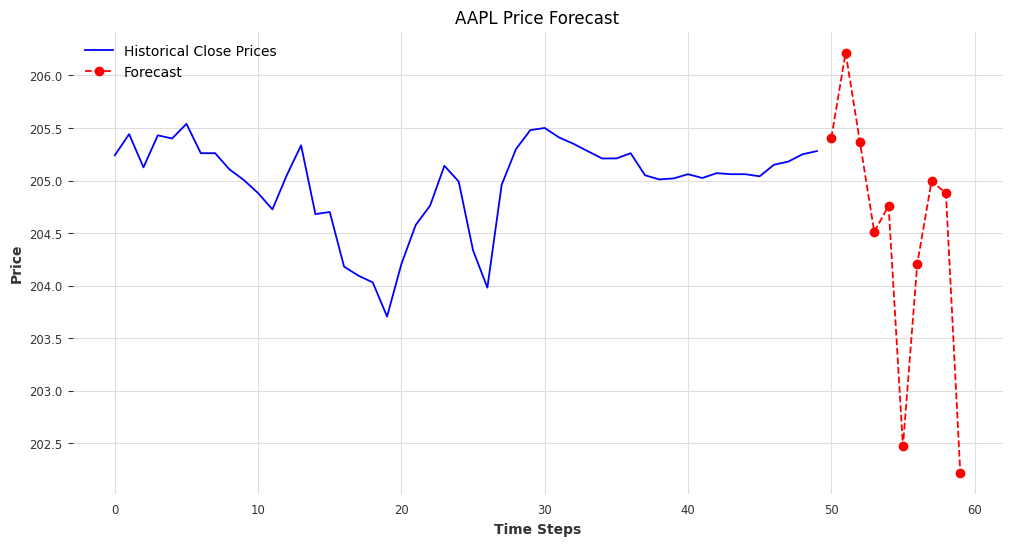

In [40]:
import matplotlib.pyplot as plt

# Get the last 50 values from live_df['Close']
last_50_closes = live_df['close'].iloc[-50:].values  # Convert to array

# Extract forecast values
forecast_values = scaler2.inverse_transform(forecast).values().flatten()  # Convert to 1D array

# Create continuous indices
historical_index = range(len(last_50_closes))
forecast_index = range(len(last_50_closes), len(last_50_closes) + len(forecast_values))

# Plot historical close prices
plt.figure(figsize=(12, 6))
plt.plot(historical_index, last_50_closes, label="Historical Close Prices", color="blue")

# Plot the forecasted values
plt.plot(forecast_index, forecast_values, label="Forecast", color="red", linestyle="dashed", marker="o")

# Formatting
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.title(f"{ticker} Price Forecast")
plt.legend()
plt.grid(True)
plt.show()


<h1>Let the tests begin:</h1>

In [41]:
def create_df(data):
    results = data.get("results", [])  # Extract the actual data list

    if not results:
        return pd.DataFrame()  # Return empty DataFrame if no data is available
    
    df = pd.DataFrame(results)
    df["timestamp"] = pd.to_datetime(df["t"], unit="ms")  # Convert timestamp
    df = df[["timestamp", "o", "h", "l", "c", "v"]]  # Keep relevant columns
    df.columns = ["Timestamp", "Open", "High", "Low", "Close", "Volume"]
    
    return df


#df_15min = create_df(data_15min)
#df_1min = create_df(data_1min)
#df_1h = create_df(data_1h)

In [42]:
import requests

API_KEY = "6FScTtPXo3hC4lyzkRb29mNJOOmLYwYF"
ticker = "NVDA"
pre_date = "2025-02-01"
date = "2025-02-28"

url_15min = f"https://api.polygon.io/v2/aggs/ticker/AAPL/range/5/minute/{pre_date}/{date}?adjusted=true&sort=asc&apiKey=LTikapZvdZjraWfVP2r_QgAvTX_oZSZw"
#url_1min = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/1/minute/{pre_date}/{date}?adjusted=true&sort=asc&apiKey={API_KEY}"
#url_1h = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/1/hour/{pre_date}/{date}?adjusted=true&sort=asc&apiKey={API_KEY}"

response_15min = requests.get(url_15min)
#response_1min = requests.get(url_1min)
#response_1h = requests.get(url_1h)

data_15min = response_15min.json()
#data_1min = response_1min.json()
#data_1h = response_1h.json()
df_15min = create_df(data_15min)

In [43]:
df_15min.Timestamp

0      2025-02-03 09:00:00
1      2025-02-03 09:05:00
2      2025-02-03 09:10:00
3      2025-02-03 09:15:00
4      2025-02-03 09:20:00
               ...        
1206   2025-02-11 16:45:00
1207   2025-02-11 16:50:00
1208   2025-02-11 16:55:00
1209   2025-02-11 17:00:00
1210   2025-02-11 17:05:00
Name: Timestamp, Length: 1211, dtype: datetime64[ns]

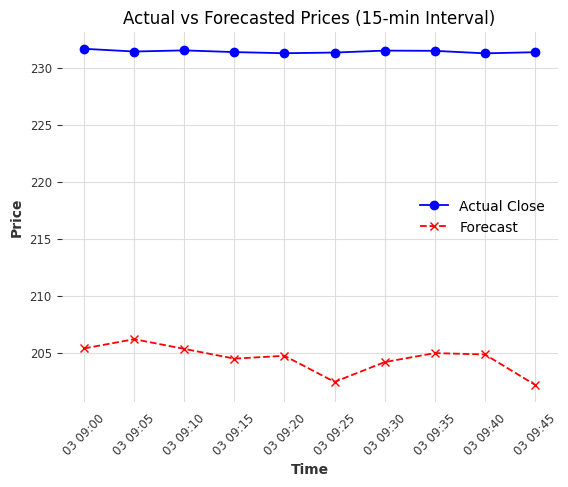

In [44]:
# Ensure df_15min has enough data

if len(df_15min) < len(forecast_values):
    print("Warning: df_15min has fewer data points than forecast_values!")

# Select the first len(forecast_values) close prices from df_15min
actual_close = df_15min["Close"].iloc[:len(forecast_values)].values

# Create a time index based on df_15min timestamps
timestamps = df_15min["Timestamp"].iloc[:len(forecast_values)]

# Plot actual close prices
plt.plot(timestamps, actual_close, marker='o', label="Actual Close", color='blue')

# Plot forecast values
plt.plot(timestamps, forecast_values, marker='x', linestyle='dashed', label="Forecast", color='red')

# Labels and title
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Actual vs Forecasted Prices (15-min Interval)")
plt.legend()
plt.xticks(rotation=45)

# Show the plot
plt.show()

In [45]:
forecast_values

array([205.40489, 206.21649, 205.36545, 204.51094, 204.75987, 202.47133,
       204.20677, 204.99536, 204.87877, 202.21802], dtype=float32)

In [46]:
def make_markov_chain_transition_matrix(df, close_column_name="close"):
    transition_matrix = np.zeros((2, 2))
    df["Trend"] = np.where(df[close_column_name].diff() > 0, 1, 0)
    for i in range(1, len(df)):
        prev_state = df["Trend"].iloc[i - 1]
        curr_state = df["Trend"].iloc[i]
        transition_matrix[prev_state, curr_state] += 1
    transition_matrix = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)
    transition_matrix = np.nan_to_num(transition_matrix, nan=0.5)  # Fix NaN cases
    return transition_matrix
def predict_next_trend(current_state, transition_matrix):
    return np.random.choice([0, 1], p=transition_matrix[current_state])

In [47]:
live_df_copy = live_df.copy()
transition_matrix = make_markov_chain_transition_matrix(live_df_copy, close_column_name="close")

trend = predict_next_trend(live_df_copy["Trend"].iloc[-1], transition_matrix)
print(f"Predicted Next Trend: {'Bullish' if trend == 1 else 'Bearish'}")

Predicted Next Trend: Bullish


In [48]:
def calculate_adx_rsi(df, high_col="High", low_col="Low", close_col="Close", period=14):
    df = df.copy()
    df["TR"] = np.maximum(df[high_col] - df[low_col], 
                          np.maximum(abs(df[high_col] - df[close_col].shift(1)), 
                                     abs(df[low_col] - df[close_col].shift(1))))
    
    df["+DM"] = np.where((df[high_col] - df[high_col].shift(1)) > (df[low_col].shift(1) - df[low_col]),
                         np.maximum(df[high_col] - df[high_col].shift(1), 0), 0)
    df["-DM"] = np.where((df[low_col].shift(1) - df[low_col]) > (df[high_col] - df[high_col].shift(1)),
                         np.maximum(df[low_col].shift(1) - df[low_col], 0), 0)
    df["ATR"] = df["TR"].rolling(window=period).mean()
    df["+DM_Smooth"] = df["+DM"].rolling(window=period).mean()
    df["-DM_Smooth"] = df["-DM"].rolling(window=period).mean()
    df["+DI"] = (df["+DM_Smooth"] / df["ATR"]) * 100
    df["-DI"] = (df["-DM_Smooth"] / df["ATR"]) * 100
    df["DX"] = (abs(df["+DI"] - df["-DI"]) / (df["+DI"] + df["-DI"])) * 100
    df["ADX"] = df["DX"].rolling(window=period).mean()
    delta = df[close_col].diff(1)
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)

    avg_gain = pd.Series(gain).rolling(window=period, min_periods=1).mean()
    avg_loss = pd.Series(loss).rolling(window=period, min_periods=1).mean()

    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))
    last_adx = df["ADX"].iloc[-1]
    last_rsi = df["RSI"].iloc[-1]
    trend_confirmed = last_adx > 25
    rsi_divergence = last_rsi > 70 or last_rsi < 30

    return trend_confirmed, rsi_divergence

In [49]:
trend_confirmed, rsi_divergence = calculate_adx_rsi(live_df_copy, high_col="high", low_col="low", close_col="close")

print(f"Trend Confirmed: {trend_confirmed}")
print(f"RSI Divergence Detected: {rsi_divergence}")

Trend Confirmed: False
RSI Divergence Detected: False


# Strat 1: Markov-Validated Trend Following

## **Entry Criteria:**
1. **Markov Chain Validation (60min future check)**
   - States:  
     - `0` → Bearish  
     - `1` → Bullish  
   - Confirms if the trend state aligns with the TFT forecast.

2. **Secondary Confirmation:**
   - **ADX > 25** → Strong trend confirmation  
   - **RSI Divergence** → Avoid false signals

3. **Buy Execution:**
   - **Entry Price**: Around the **minimum** price of the 15min TFT forecast.
   - **Trade Log**: Save in a JSON file (`time`, `close`, `open`, `order type`).

---

## **Exit Strategy:**
1. **Monitor 1min Data for Peak Exit:**
   - Close position when price **exceeds** forecasted peak.
   - Alternatively, use **trend-based stop (Technical.py)**:
     - **1 → Uptrend:** Hold  
     - **0 → Downtrend:** Exit at peak

2. **Adaptive Stop-Loss:**
   - **ATR-based trailing stop** to adjust dynamically.
   - **Time-based exit** (e.g., if price doesn’t move in 2 hours, cut loss).

3. **Profit-Taking Mechanism:**
   - **Partial exits** at 0.5% and 1% move.
   - **Dynamic trailing stop** using last peak.

---

## **Risk Management Enhancements:**
**Kelly Criterion for Position Sizing**  
**Avoid Execution Slippage** (Simulate real spreads)  
**Order Book Analysis for Institutional Activity**  
**Options Flow to Detect Large Moves**  
---

Would you like to integrate a **backtesting module** to analyze performance before live trading? 


<h1>Testing Strats:</h1>

<h2>Strat 1:</h2>

In [50]:
from datetime import datetime, timedelta
import pandas as pd
import requests

def fetch_polygon_data(ticker, timespan, first_pred=False, limit=500, intervel_time=15):
    """Fetch historical data from Polygon.io."""
    api_key = "6FScTtPXo3hC4lyzkRb29mNJOOmLYwYF"
    end_date = datetime.now()
    
    if first_pred:
        live_df = pd.read_csv(f"{ticker}/{ticker}_Live_Data.csv")
        live_df['timestamp'] = pd.to_datetime(live_df['timestamp'], errors='coerce')
        # Use the day before the first timestamp in live_df
        live_date = pd.to_datetime(live_df['timestamp'].iloc[0]) - pd.Timedelta(days=1)
        # Format the date as YYYY-MM-DD for Polygon API
        start_date = live_date.strftime("%Y-%m-%d")
    else:
        start_date = (end_date - timedelta(days=5)).strftime("%Y-%m-%d")
    
    formatted_end_date = end_date.strftime("%Y-%m-%d")
    
    url = (f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/{intervel_time}/{timespan}/"
           f"{start_date}/{formatted_end_date}?adjusted=true&sort=desc&limit={limit}&apiKey={api_key}")
    
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        if "results" in data:
            df = pd.DataFrame(data["results"])
            df["timestamp"] = pd.to_datetime(df["t"], unit="ms")
            return df[["timestamp", "o", "h", "l", "c", "v"]].rename(
                columns={"o": "open", "h": "high", "l": "low", "c": "close", "v": "volume"})
    return pd.DataFrame()


In [51]:
def is_market_open():
    """Check if the market is currently open using Polygon's market status endpoint."""
    api_key = "6FScTtPXo3hC4lyzkRb29mNJOOmLYwYF"
    url = f"https://api.polygon.io/v1/marketstatus/now?apiKey={api_key}"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return data.get("market", "closed") == "open"
    return False

In [52]:
import pandas as pd
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

def buy_signal(min_df, static_covariates, forecasting_horizon,n = 10, first_pred=False):
    '''
    Model parameters:
    output_chunk_length: 20
    num_attention_heads: 2
    n_epochs: 8
    lstm_layers: 1
    input_chunk_length: 100  
    hidden_size: 24
    dropout: 0.2
    batch_size: 32
    use_static_covariates: True
    add_encoders: {'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 
                   'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 
                   'position': {'past': ['relative'], 'future': ['relative']}, 
                   'custom': {'past': [<function encode_hour at 0x00000181ED22B040>], 
                              'future': [<function encode_hour at 0x00000181ED22B040>]}, 
                   'transformer': Scaler, 'tz': 'CET'}
    pl_trainer_kwargs: {'accelerator': 'cpu'}
    '''
    """
    Determines a buy signal based on technical indicators, a Markov Chain trend, and a TFT model forecast.
    
    Parameters:
        n_df (DataFrame): Higher timeframe DataFrame (e.g., 15min data) with at least a 'close' column.
        min_df (DataFrame): Minute-level DataFrame used for technical indicator calculations (ADX, RSI, etc.).
        n (int): Number of time steps used for shifting to create the target column.
        static_covariates (DataFrame): Static covariates for the TimeSeries.
        forecasting_horizon (int): Number of steps ahead to forecast.
        first_pred (bool): Flag for first prediction logic.
        
    Returns:
        bool: The resulting buy signal.
    """
    # Apply technical indicators (assumed to be defined elsewhere)
    n_df = technical_df = technical_polygon(symbol = ticker, interval = interval, interval_range = interval_range, days = days)
    n_df = technical_df
    n_df.reset_index(inplace=True)
        # … after fetching technical_df & resetting index …

    # 1) Keep only features up to 'Stochastic'
    features_df = n_df.loc[:, :'Stochastic'].copy()

    # 2) Now add your target column 'y'
    features_df['y'] = n_df['close']

    # 3) Drop any rows with NaNs (e.g. if you had shifted)
    features_df.dropna(inplace=True)

    # 4) Reassign back to n_df for the rest of your code
    n_df = features_df
    
    if n_df['timestamp'].iloc[-1] < n_df['timestamp'].iloc[0]:
        n_df = n_df.iloc[::-1].reset_index(drop=True)

    # Create a Darts TimeSeries using the 'y' column as the target.
    series = TimeSeries.from_dataframe(
        n_df,
        value_cols='y',
        time_col='timestamp',
        fill_missing_dates=True,
        freq="5T",  
        static_covariates=static_covariates
    )
    
    # Cast the series to float32 to ensure compatibility with the model
    series = series.astype("float32")
    
    # Normalize input data using a Scaler
    scaler2 = Scaler()
    past_covariates_transformed = scaler2.fit_transform(series)
    
    # --- Debug prints for past covariates ---
    past_covariates_df = past_covariates_transformed.pd_dataframe()
    current_end = past_covariates_transformed.end_time()
    
    # Print model specifications (assumes a global variable 'model')
    print("Model specifications:")
    print(model)

    
    # The model expects the past covariates to extend until 2025-03-11 14:30:00.
    required_end = pd.Timestamp("2025-03-11 14:30:00")
    freq = pd.Timedelta(minutes=5)
    if current_end < required_end:
        extra_steps = int(((required_end - current_end).total_seconds() / 300) + 1)
        print("Extending past covariates by", extra_steps, "steps")
        last_val = past_covariates_transformed.last_value()
        extra_times = pd.date_range(start=current_end + freq, periods=extra_steps, freq="5T")
        extra_series = TimeSeries.from_times_and_values(extra_times, [last_val]*extra_steps)
        past_covariates_transformed = past_covariates_transformed.concatenate(extra_series)
    
    # Ensure past_covariates_transformed is float32 after extension
    past_covariates_transformed = past_covariates_transformed.astype("float32")
    
    print("Past covariates end_time after extension:", past_covariates_transformed.end_time())
    
    # --- Forecast using the trained model ---
    # IMPORTANT: Pass both the target series and the past covariates.
    forecast = model.predict(n=forecasting_horizon,
                             series=series, 
                             past_covariates=past_covariates_transformed)
    
    forecast_values = scaler2.inverse_transform(forecast).values().flatten()
    forecast_df = pd.DataFrame({"forecast_values": forecast_values})
    
    # Calculate ADX and RSI from minute-level data (assumed defined elsewhere)
    trend_confirmed, rsi_divergence = calculate_adx_rsi(min_df, high_col="high", low_col="low", close_col="close")
    
    # Predict next trend using Markov Chain (assumed defined elsewhere)
    transition_matrix = make_markov_chain_transition_matrix(n_df, close_column_name="close")
    trend = predict_next_trend(n_df["Trend"].iloc[-1], transition_matrix)
    
    # Compute conditions based on the first close price and forecasted mean

    # Calculate % difference between close[1] and close[0]
    close_diff = abs(n_df['close'].iloc[1] - n_df['close'].iloc[0]) / n_df['close'].iloc[0]

    # Calculate % difference between forecast[1] and forecast[0]
    forecast_diff = abs(forecast_df['forecast_values'].iloc[1] - forecast_df['forecast_values'].iloc[0]) / forecast_df['forecast_values'].iloc[0]

    # Compare the differences
    first_a = close_diff < forecast_diff
    
    a = forecast_df['forecast_values'].iloc[3] < forecast_df['forecast_values'].mean()
    
    print("First condition, prediction based):", first_a)
    
    if  first_a:
        return True
    else:
        return False


In [53]:
def is_market_open():
    return True

In [54]:
time_slept = 60 * 2 # N minutes between checks
results_df = pd.DataFrame(columns=["Timestamp", "Buy_Signal", "Close"])
this_is_a_test = False
first_pred = True

# Strat 2: Markov-Validated Trend Following BEARISH BASED

## **Entry Criteria:**
1. **Markov Chain Validation (60min future check)**
   - States:  
     - `0` → Bearish  
     - `1` → Bullish  
   - Confirms if the trend state aligns with the TFT forecast.

2. **Secondary Confirmation:**
   - **ADX > 25** → Strong trend confirmation  
   - **RSI Divergence** → Avoid false signals

3. **Buy Execution:**
   - **Entry Price**: Around the **minimum** price of the 15min TFT forecast.
   - **Trade Log**: Save in a JSON file (`time`, `close`, `open`, `order type`).

---

## **Exit Strategy:**
1. **Monitor 1min Data for Peak Exit:**
   - Close position when price **exceeds** forecasted peak.
   - Alternatively, use **trend-based stop (Technical.py)**:
     - **1 → Uptrend:** Hold  
     - **0 → Downtrend:** Exit at peak

2. **Adaptive Stop-Loss:**
   - **ATR-based trailing stop** to adjust dynamically.
   - **Time-based exit** (e.g., if price doesn’t move in 2 hours, cut loss).

3. **Profit-Taking Mechanism:**
   - **Partial exits** at 0.5% and 1% move.
   - **Dynamic trailing stop** using last peak.

---

## **Risk Management Enhancements:**
**Kelly Criterion for Position Sizing**  
**Avoid Execution Slippage** (Simulate real spreads)  
**Order Book Analysis for Institutional Activity**  
**Options Flow to Detect Large Moves**  
---



In [55]:
# ib_trading_fixed.py

import threading
import time
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from ibapi.order import Order

class IBApi(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.nextOrderId = None
        self.connected_evt = threading.Event()

    def nextValidId(self, orderId: int):
        self.nextOrderId = orderId
        self.connected_evt.set()
        print(f"[IB] Next valid order ID: {orderId}")

    def orderStatus(self, orderId, status, filled, remaining, avgFillPrice,
                    permId, parentId, lastFillPrice, clientId, whyHeld, mktCapPrice):
        print(f"[ORDER STATUS] ID={orderId} status={status} filled={filled} "
              f"remaining={remaining} avgFillPrice={avgFillPrice}")

    def error(self, reqId, errorCode, errorString):
        print(f"[ERROR] reqId={reqId} code={errorCode} msg={errorString}")

class IBTradingBot:
    def __init__(self, symbol: str, quantity: int = 1, use_market: bool = True):
        self.symbol     = symbol
        self.quantity   = quantity
        self.use_market = use_market
        self.ib         = IBApi()
        self.clientId   = 1
        self.port       = 7496   # paper trading
        self.host       = "127.0.0.1"

    def connect(self):
        self.ib.connect(self.host, self.port, self.clientId)
        thread = threading.Thread(target=self.ib.run, daemon=True)
        thread.start()
        print("[IB] Connecting...")
        if not self.ib.connected_evt.wait(5):
            raise RuntimeError("❌ nextValidId not received")
        print("[IB] Connected!")

    def disconnect(self):
        self.ib.disconnect()
        print("[IB] Disconnected!")

    def make_contract(self) -> Contract:
        c = Contract()
        c.symbol           = self.symbol
        c.secType          = "STK"
        c.exchange         = "SMART"
        c.primaryExchange  = "ISLAND"   # NASDAQ routing
        c.currency         = "USD"
        return c

    def make_order(self, action: str) -> Order:
        o = Order()
        o.action           = action
        o.totalQuantity    = self.quantity
        if self.use_market:
            o.orderType    = "MKT"
        else:
            o.orderType    = "LMT"
            o.lmtPrice     = 150.00    # or fetch dynamically

        # explicitly set these to blank to suppress warnings
        o.eTradeOnly       = ""
        o.firmQuoteOnly    = ""

        o.tif              = "DAY"
        o.transmit         = True
        return o

    def place(self, action: str):
        if self.ib.nextOrderId is None:
            raise RuntimeError("❌ No nextOrderId; did you connect?")
        oid = self.ib.nextOrderId
        self.ib.nextOrderId += 1

        contract = self.make_contract()
        order    = self.make_order(action)

        print(f"[ORDER] Placing {action} for {self.symbol} x{self.quantity}")
        self.ib.placeOrder(oid, contract, order)

    def buy(self):
        self.place("BUY")

    def sell(self):
        self.place("SELL")

    def run_demo(self):
        try:
            self.connect()
            self.buy()
            time.sleep(5)    # wait for status updates
        finally:
            self.disconnect()


In [58]:
import pandas as pd
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

def buy_signal(n_df, min_df, static_covariates, forecasting_horizon, n = 10, first_pred=False):
    '''
    Model parameters:
    output_chunk_length: 20
    num_attention_heads: 2
    n_epochs: 8
    lstm_layers: 1
    input_chunk_length: 100  
    hidden_size: 24
    dropout: 0.2
    batch_size: 32
    use_static_covariates: True
    add_encoders: {'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 
                   'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 
                   'position': {'past': ['relative'], 'future': ['relative']}, 
                   'custom': {'past': [<function encode_hour at 0x00000181ED22B040>], 
                              'future': [<function encode_hour at 0x00000181ED22B040>]}, 
                   'transformer': Scaler, 'tz': 'CET'}
    pl_trainer_kwargs: {'accelerator': 'cpu'}
    '''
    """
    Determines a buy signal based on technical indicators, a Markov Chain trend, and a TFT model forecast.
    
    Parameters:
        n_df (DataFrame): Higher timeframe DataFrame (e.g., 15min data) with at least a 'close' column.
        min_df (DataFrame): Minute-level DataFrame used for technical indicator calculations (ADX, RSI, etc.).
        n (int): Number of time steps used for shifting to create the target column.
        static_covariates (DataFrame): Static covariates for the TimeSeries.
        forecasting_horizon (int): Number of steps ahead to forecast.
        first_pred (bool): Flag for first prediction logic.
        
    Returns:
        bool: The resulting buy signal.
    """
    # Apply technical indicators (assumed to be defined elsewhere)
    n_df = technical_indicators(n_df)
    n_df.reset_index(inplace=True)
        # … after fetching technical_df & resetting index …

    # 1) Keep only features up to 'Stochastic'
    features_df = n_df.loc[:, :'Stochastic'].copy()

    # 2) Now add your target column 'y'
    features_df['y'] = n_df['close']

    # 3) Drop any rows with NaNs (e.g. if you had shifted)
    features_df.dropna(inplace=True)

    # 4) Reassign back to n_df for the rest of your code
    n_df = features_df
    
    if n_df['timestamp'].iloc[-1] < n_df['timestamp'].iloc[0]:
        n_df = n_df.iloc[::-1].reset_index(drop=True)
    print(n_df['timestamp'].iloc[0])
    print(n_df['timestamp'].iloc[-1])
    # Create a Darts TimeSeries using the 'y' column as the target.
    series = TimeSeries.from_dataframe(
        n_df,
        value_cols='y',
        time_col='timestamp',
        fill_missing_dates=True,
        freq="5T",  
        static_covariates=static_covariates
    )
    
    # Cast the series to float32 to ensure compatibility with the model
    series = series.astype("float32")
    
    # Normalize input data using a Scaler
    scaler2 = Scaler()
    past_covariates_transformed = scaler2.fit_transform(series)
    
    # --- Debug prints for past covariates ---
    past_covariates_df = past_covariates_transformed.pd_dataframe()
    current_end = past_covariates_transformed.end_time()
    
    # Print model specifications (assumes a global variable 'model')
    print("Model specifications:")
    print(model)

    
    # The model expects the past covariates to extend until 2025-03-11 14:30:00.
    required_end = pd.Timestamp("2025-03-11 14:30:00")
    freq = pd.Timedelta(minutes=5)
    if current_end < required_end:
        extra_steps = int(((required_end - current_end).total_seconds() / 300) + 1)
        print("Extending past covariates by", extra_steps, "steps")
        last_val = past_covariates_transformed.last_value()
        extra_times = pd.date_range(start=current_end + freq, periods=extra_steps, freq="5T")
        extra_series = TimeSeries.from_times_and_values(extra_times, [last_val]*extra_steps)
        past_covariates_transformed = past_covariates_transformed.concatenate(extra_series)
    
    # Ensure past_covariates_transformed is float32 after extension
    past_covariates_transformed = past_covariates_transformed.astype("float32")
    
    print("Past covariates end_time after extension:", past_covariates_transformed.end_time())
    
    # --- Forecast using the trained model ---
    # IMPORTANT: Pass both the target series and the past covariates.
    forecast = model.predict(n=forecasting_horizon,
                             series=series, 
                             past_covariates=past_covariates_transformed)
    
    forecast_values = scaler2.inverse_transform(forecast).values().flatten()
    forecast_df = pd.DataFrame({"forecast_values": forecast_values})
    
    # Calculate ADX and RSI from minute-level data (assumed defined elsewhere)
    trend_confirmed, rsi_divergence = calculate_adx_rsi(min_df, high_col="high", low_col="low", close_col="close")
    
    # Predict next trend using Markov Chain (assumed defined elsewhere)
    transition_matrix = make_markov_chain_transition_matrix(n_df, close_column_name="close")
    trend = predict_next_trend(n_df["Trend"].iloc[-1], transition_matrix)
    
    # Compute conditions based on the first close price and forecasted mean

    # Calculate % difference between close[1] and close[0]
    close_diff = abs(n_df['close'].iloc[1] - n_df['close'].iloc[0]) / n_df['close'].iloc[0]

    # Calculate % difference between forecast[1] and forecast[0]
    forecast_diff = abs(forecast_df['forecast_values'].iloc[1] - forecast_df['forecast_values'].iloc[0]) / forecast_df['forecast_values'].iloc[0]

    # Compare the differences
    first_a = close_diff < forecast_diff
    
    a = forecast_df['forecast_values'].iloc[3] < forecast_df['forecast_values'].mean()
    
    print("First condition, prediction based):", first_a)
    
    if  first_a:
        return True
    else:
        return False


In [ ]:
import threading
import time
import requests
import pandas as pd

from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
from ibapi.order import Order

# ─────────────────────────────────────────────────────────────────────────────
#  AlphaVantage price fetch (free)
ALPHA_KEY = "F1UXC7ZGHIEUFHUN"
def get_price_from_alpha(symbol: str,
                         interval: str = "1min",
                         output_size: str = "compact") -> float:
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_INTRADAY",
        "symbol": symbol,
        "interval": interval,
        "apikey": ALPHA_KEY,
        "outputsize": output_size,
    }
    r = requests.get(url, params=params, timeout=5)
    data = r.json()
    ts = data.get(f"Time Series ({interval})")
    if not ts:
        raise RuntimeError(f"No intraday data for {symbol}")
    latest = sorted(ts.keys())[-1]
    return float(ts[latest]["4. close"])

# ─────────────────────────────────────────────────────────────────────────────
class IBApi(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.nextOrderId = None
        self.connected_evt = threading.Event()

    def nextValidId(self, orderId: int):
        self.nextOrderId = orderId
        self.connected_evt.set()
        print(f"[IB] Next valid order ID: {orderId}")

    def orderStatus(self, orderId, status, filled, remaining, avgFillPrice,
                    permId, parentId, lastFillPrice, clientId, whyHeld, mktCapPrice):
        print(f"[ORDER STATUS] ID={orderId} status={status} filled={filled} remaining={remaining} avgFillPrice={avgFillPrice}")

    def error(self, reqId, errorCode, errorString):
        print(f"[ERROR] reqId={reqId} code={errorCode} msg={errorString}")

# ─────────────────────────────────────────────────────────────────────────────
class IBTradingBot:
    def __init__(self, usd_amount: float = 150.0):
        self.usd_amount = usd_amount
        self.ib = IBApi()
        self.clientId = 1
        self.port = 7496   # paper trading
        self.host = "127.0.0.1"
        self.pos = 0

    def connect(self):
        self.ib.connect(self.host, self.port, self.clientId)
        thread = threading.Thread(target=self.ib.run, daemon=True)
        thread.start()
        print("[IB] Connecting...")
        if not self.ib.connected_evt.wait(5):
            raise RuntimeError("❌ nextValidId not received")
        print("[IB] Connected!")

    def disconnect(self):
        self.ib.disconnect()
        print("[IB] Disconnected!")

    def make_contract(self, symbol: str) -> Contract:
        c = Contract()
        c.symbol = symbol
        c.secType = "STK"
        c.exchange = "SMART"
        c.primaryExchange = "ISLAND"
        c.currency = "USD"
        return c

    def place_market_order(self, symbol: str, action: str):
        price = get_price_from_alpha(symbol)
        qty = max(int(self.usd_amount // price), 1)
        if self.ib.nextOrderId is None:
            raise RuntimeError("❌ No nextOrderId; did you connect?")
        oid = self.ib.nextOrderId
        self.ib.nextOrderId += 1

        contract = self.make_contract(symbol)
        order = Order()
        order.action = action
        order.orderType = "MKT"
        order.totalQuantity = qty
        order.eTradeOnly = ""
        order.firmQuoteOnly = ""
        order.tif = "DAY"
        order.transmit = True

        print(f"[ORDER] {action} {qty}×{symbol} (~${qty*price:.2f}) (orderId={oid})")
        self.ib.placeOrder(oid, contract, order)

    def buy(self, symbol: str):
        self.place_market_order(symbol, "BUY")
        self.pos = 1

    def close_buy(self, symbol: str):
        self.place_market_order(symbol, "SELL")
        self.pos = 0

# ─────────────────────────────────────────────────────────────────────────────
def get_twelvedata_minute(ticker, api_key = "f13c5ee6ed5c46c99e5a4022dc41d02f", interval = "1min"):
    url = f"https://api.twelvedata.com/time_series?symbol={ticker}&interval={interval}&apikey={api_key}&outputsize=1"
    response = requests.get(url).json()
    if "values" not in response:
        raise Exception("Error: " + str(response))
    data = response["values"][0]
    return {
        "timestamp": data["datetime"],
        "open": float(data["open"]),
        "high": float(data["high"]),
        "low": float(data["low"]),
        "close": float(data["close"]),
        "volume": float(data["volume"])
    }

def append_to_df(ticker, df, api_key = "f13c5ee6ed5c46c99e5a4022dc41d02f", interval = "1min"):
    # Get the new row
    new_row = get_twelvedata_minute(ticker, api_key)
    
    # Append and save
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    print("Row appended.")
    return df
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    bot = IBTradingBot(usd_amount=150.0)
    ticker = "NVDA"
    interval_range = 5
    forecasting_horizon = 20
    static_covariates = None
    this_is_a_test = False
    first_pred = True
    results_df = pd.DataFrame(columns=["timestamp", "Buy_Signal", "close"] )

    bot.connect()
    try:
        while True:
            if (is_market_open() or this_is_a_test) and first_pred:
                first_pred = False
                df_1min = fetch_polygon_data(ticker, "minute", limit=1000,
                                             intervel_time=f"{round(1.1)}")

                df_15min = fetch_polygon_data(ticker, "minute", limit=1000, 
                                              intervel_time=f'{interval_range}')
                if df_1min['timestamp'].iloc[-1] < df_1min['timestamp'].iloc[0]:
                    df_1min = df_1min.iloc[::-1].reset_index(drop=True)

                if df_15min['timestamp'].iloc[-1] < df_15min['timestamp'].iloc[0]:
                    df_15min = df_15min.iloc[::-1].reset_index(drop=True)
                signal = buy_signal(n_df = df_15min, min_df=df_1min,
                                     static_covariates=static_covariates,
                                     first_pred=first_pred,
                                     n=forecasting_horizon,
                                     forecasting_horizon=forecasting_horizon)
                print(f"Signal: {signal}")

                if signal == "buy" and bot.pos == 0:
                    print("Buy signal detected")
                    bot.buy(ticker)
                elif signal == "sell" and bot.pos == 1:
                    print("Sell signal detected")
                    bot.close_buy(ticker)

                results_df = pd.concat([
                    results_df,
                    pd.DataFrame({
                        "timestamp": [df_1min['timestamp'].iloc[-1]],
                        "Buy_Signal": [signal],
                        "close": [df_1min['close'].iloc[-1]]
                    })
                ], ignore_index=True)

                if this_is_a_test:
                    break
                first_pred = False
                time.sleep(120)

            elif (is_market_open() or this_is_a_test) and first_pred == False:
                df_1min = append_to_df(ticker = ticker, df = df_1min, interval = "1min")
                df_15min = append_to_df(ticker = ticker, df =  df_15min, interval = "15min")
                if df_1min['timestamp'].iloc[-1] < df_1min['timestamp'].iloc[0]:
                    df_1min = df_1min.iloc[::-1].reset_index(drop=True)

                if df_15min['timestamp'].iloc[-1] < df_15min['timestamp'].iloc[0]:
                    df_15min = df_15min.iloc[::-1].reset_index(drop=True)
                signal = buy_signal(n_df = df_15min, min_df=df_1min,
                                     static_covariates=static_covariates,
                                     first_pred=first_pred,
                                     n=forecasting_horizon,
                                     forecasting_horizon=forecasting_horizon)

                print(f"Signal: {signal}")

                if signal == "buy" and bot.pos == 0:
                    print("Buy signal detected")
                    bot.buy(ticker)
                elif signal == "sell" and bot.pos == 1:
                    print("Sell signal detected")
                    bot.close_buy(ticker)

                results_df = pd.concat([
                    results_df,
                    pd.DataFrame({
                        "timestamp": [df_1min['timestamp'].iloc[-1]],
                        "Buy_Signal": [signal],
                        "close": [df_1min['close'].iloc[-1]]
                        })
                    ], ignore_index=True)

            if this_is_a_test:
                first_pred = False
                break
            else:
                print("Market is closed. Waiting...")
                time.sleep(120)
    finally:
        results_df.to_csv(f"{ticker}_buy_signals.csv", index=False)
        print("Results saved.")
        bot.disconnect()


[IB] Next valid order ID: 2[IB] Connecting...
[IB] Connected!

[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:hfarm
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:usfarm.nj
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:jfarm
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:usfuture
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:eufarm
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:cashfarm
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:eufarmnj
[ERROR] reqId=-1 code=2104 msg=Market data farm connection is OK:usfarm
[ERROR] reqId=-1 code=2106 msg=HMDS data farm connection is OK:euhmds
[ERROR] reqId=-1 code=2106 msg=HMDS data farm connection is OK:fundfarm
[ERROR] reqId=-1 code=2106 msg=HMDS data farm connection is OK:ushmds
[ERROR] reqId=-1 code=2158 msg=Sec-def data farm connection is OK:secdefeu


C:\Users\david\AppData\Local\anaconda3\envs\tws_env\lib\site-packages\darts\timeseries.py:4870: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_time_index = resampled_time_index.asfreq(freq)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


2025-05-02 09:30:00
2025-05-02 23:55:00
Model specifications:
TFTModel(hidden_size=24, num_attention_heads=2, dropout=0.2, output_chunk_length=20, n_epochs=8, input_chunk_length=120, batch_size=32, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_hour at 0x0000021E139CB940>], 'future': [<function encode_hour at 0x0000021E139CB940>]}, 'transformer': Scaler, 'tz': 'CET'}, pl_trainer_kwargs={'accelerator': 'cpu'})
Past covariates end_time after extension: 2025-05-02 23:55:00


Predicting: |                                                                                    | 0/? [00:00<…

First condition, prediction based): False
Signal: False


C:\Users\david\AppData\Local\Temp\ipykernel_12680\2530796223.py:178: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([
